# Import necessary libraries

In [82]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import LineString
import utm
from sklearn.preprocessing import StandardScaler
import math

# Remove warning 

In [83]:
import warnings
warnings.filterwarnings("ignore")

# Read Dataset

In [84]:
Data_folder = 'Dataset'

# Read  data
data_files = [os.path.join(Data_folder, file) for file in os.listdir(Data_folder) if file.endswith('.csv')]
df = pd.concat([pd.read_csv(file) for file in data_files], ignore_index=True)

In [85]:
df.shape

(84593, 186)

# List the Features

In [86]:
column_names = df.columns.tolist()
print("Column Names:")
for column_name in column_names:
    print(column_name)

Column Names:
CUSTOM.date [local]
CUSTOM.updateTime [local]
OSD.flyTime
OSD.flyTime [s]
OSD.latitude
OSD.longitude
OSD.height [ft]
OSD.heightMax [ft]
OSD.vpsHeight [ft]
OSD.altitude [ft]
OSD.mileage [ft]
OSD.hSpeed [MPH]
OSD.hSpeedMax [MPH]
OSD.xSpeed [MPH]
OSD.xSpeedMax [MPH]
OSD.ySpeed [MPH]
OSD.ySpeedMax [MPH]
OSD.zSpeed [MPH]
OSD.zSpeedMax [MPH]
OSD.pitch
OSD.roll
OSD.yaw
OSD.yaw [360]
OSD.flycState
OSD.flycCommand
OSD.flightAction
OSD.gpsNum
OSD.gpsLevel
OSD.isGPSUsed
OSD.nonGPSCause
OSD.droneType
OSD.isSwaveWork
OSD.waveError
OSD.goHomeStatus
OSD.batteryType
OSD.ctrlDevice
OSD.isOnGround
OSD.isMotorOn
OSD.isMotorBlocked
OSD.motorStartFailedCause
OSD.motorFailReason
OSD.isImuPreheated
OSD.imuInitFailReason
OSD.isAcceletorOverRange
OSD.isBarometerDeadInAir
OSD.isCompassError
OSD.isGoHomeHeightModified
OSD.canIOCWork
OSD.isNotEnoughForce
OSD.isOutOfLimit
OSD.isPropellerCatapult
OSD.isVibrating
OSD.isVisionUsed
OSD.voltageWarning
GIMBAL.mode
GIMBAL.pitch
GIMBAL.roll
GIMBAL.yaw
GIMBAL

# Feature Selection

In [87]:
features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder','OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

In [88]:
df=df[features]
df

,OSD.flyTime,RC.aileron,RC.elevator,RC.throttle,RC.rudder,OSD.longitude,OSD.latitude,OSD.height [ft],OSD.pitch,OSD.roll,OSD.yaw
0,0m 0.0s,1024,1024,1024,1024,80.353166,7.498430,0.0,5.7,2.5,113.9
1,0m 0.1s,1024,1024,1024,1024,80.353166,7.498430,0.0,5.7,2.5,114.0
2,0m 0.2s,1024,1024,1024,1024,80.353166,7.498430,0.0,5.7,2.5,114.0
3,0m 0.3s,1024,1024,1024,1024,80.353166,7.498430,0.0,5.7,2.5,114.0
4,0m 0.4s,1024,1024,1024,1024,80.353166,7.498429,0.0,5.7,2.5,114.1
...,...,...,...,...,...,...,...,...,...,...,...
84588,10m 14.7s,1024,1024,364,1024,79.915921,6.972900,1.6,6.0,-0.4,-81.7
84589,10m 14.8s,1024,1024,364,1024,79.915921,6.972900,1.6,6.4,-0.4,-82.6
84590,10m 14.9s,1024,1024,364,1024,79.915921,6.972900,1.6,6.8,-0.4,-83.1
84591,10m 15.0s,1024,1024,364,1024,79.915921,6.972900,1.6,7.3,-1.0,-83.6


# Remove duplicate data points

In [89]:
import pandas as pd

# Assuming 'df' is your DataFrame

# Find and display the duplicate rows
duplicate_rows = df[df.duplicated()]
print("Duplicate Rows:")
duplicate_rows.head()

# Count the number of duplicate rows
num_duplicate_rows = len(duplicate_rows)
print("Number of duplicate rows:", num_duplicate_rows)


Duplicate Rows:
Number of duplicate rows: 6675


In [90]:
# Remove duplicate rows and get the original DataFrame without duplicates
df_without_duplicates = df.drop_duplicates()

# Display the original DataFrame without duplicates
print("Original DataFrame without duplicates:")
df=df_without_duplicates
df

Original DataFrame without duplicates:


,OSD.flyTime,RC.aileron,RC.elevator,RC.throttle,RC.rudder,OSD.longitude,OSD.latitude,OSD.height [ft],OSD.pitch,OSD.roll,OSD.yaw
0,0m 0.0s,1024,1024,1024,1024,80.353166,7.498430,0.0,5.7,2.5,113.9
1,0m 0.1s,1024,1024,1024,1024,80.353166,7.498430,0.0,5.7,2.5,114.0
2,0m 0.2s,1024,1024,1024,1024,80.353166,7.498430,0.0,5.7,2.5,114.0
3,0m 0.3s,1024,1024,1024,1024,80.353166,7.498430,0.0,5.7,2.5,114.0
4,0m 0.4s,1024,1024,1024,1024,80.353166,7.498429,0.0,5.7,2.5,114.1
...,...,...,...,...,...,...,...,...,...,...,...
84588,10m 14.7s,1024,1024,364,1024,79.915921,6.972900,1.6,6.0,-0.4,-81.7
84589,10m 14.8s,1024,1024,364,1024,79.915921,6.972900,1.6,6.4,-0.4,-82.6
84590,10m 14.9s,1024,1024,364,1024,79.915921,6.972900,1.6,6.8,-0.4,-83.1
84591,10m 15.0s,1024,1024,364,1024,79.915921,6.972900,1.6,7.3,-1.0,-83.6


# Convert time string to seconds function

In [75]:
def time_to_seconds(time_str):
    # Split the time string by space
    time_parts = time_str.split()
    
    # Extract minutes and seconds
    minutes = float(time_parts[0][:-1])  # Remove 'm' and convert to float
    seconds = float(time_parts[1][:-1])  # Remove 's' and convert to float
    
    # Convert to seconds
    total_seconds = (minutes * 60) + seconds
    return total_seconds

# Preprocess 'OSD.flyTime' column
df['OSD.flyTime'] = df['OSD.flyTime'].apply(time_to_seconds)


# Data Analysis

# Range of each features

Range of values for each feature:
                        min          max
RC.aileron       364.000000  1684.000000
RC.elevator      364.000000  1684.000000
RC.throttle      364.000000  1684.000000
RC.rudder        364.000000  1684.000000
OSD.longitude     79.913877    80.353385
OSD.latitude       6.972471     7.498461
OSD.height [ft]   -6.800000   115.800000
OSD.pitch        -29.400000    29.000000
OSD.roll         -25.600000    28.400000
OSD.yaw         -179.900000   179.900000


<Figure size 1200x600 with 0 Axes>

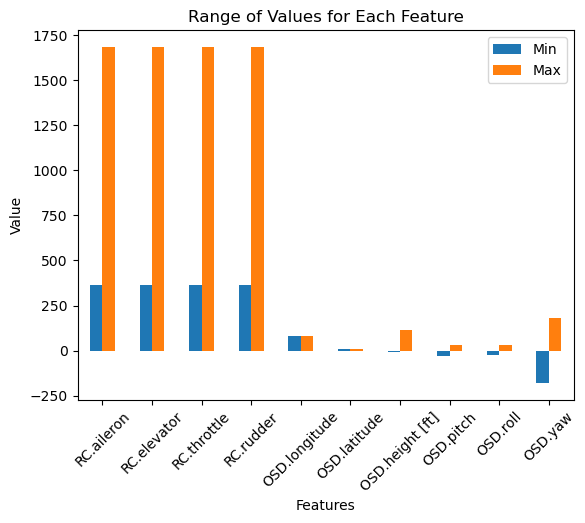

In [91]:
feature_ranges = df.describe().loc[['min', 'max']]

# Transpose the DataFrame for easier plotting
feature_ranges = feature_ranges.transpose()

print("Range of values for each feature:")
print(feature_ranges)
# Plot the range of values for each feature
plt.figure(figsize=(12, 6))
feature_ranges.plot(kind='bar', rot=45)
plt.title('Range of Values for Each Feature')
plt.xlabel('Features')
plt.ylabel('Value')
plt.legend(['Min', 'Max'])
plt.show()

In [92]:
# Calculate summary statistics for the dataset
summary_stats = df.describe()

# Display the summary statistics
summary_stats

,RC.aileron,RC.elevator,RC.throttle,RC.rudder,OSD.longitude,OSD.latitude,OSD.height [ft],OSD.pitch,OSD.roll,OSD.yaw
count,77918.000000,77918.000000,77918.000000,77918.000000,77918.000000,77918.000000,77918.000000,77918.000000,77918.000000,77918.000000
mean,1022.747286,1142.325907,992.928925,1024.964899,79.929485,6.991098,11.478610,0.609018,-0.697148,3.966399
std,43.458927,231.589450,240.138710,223.565991,0.078385,0.093826,19.620062,4.412815,2.291594,91.538409
min,364.000000,364.000000,364.000000,364.000000,79.913877,6.972471,-6.800000,-29.400000,-25.600000,-179.900000
25%,1024.000000,1024.000000,1024.000000,1024.000000,79.914270,6.972913,1.600000,-1.100000,-1.600000,-55.800000
50%,1024.000000,1024.000000,1024.000000,1024.000000,79.914786,6.974172,3.900000,1.000000,-0.500000,-2.300000
75%,1024.000000,1263.000000,1024.000000,1024.000000,79.915903,6.974350,10.100000,2.400000,0.300000,70.800000
max,1684.000000,1684.000000,1684.000000,1684.000000,80.353385,7.498461,115.800000,29.000000,28.400000,179.900000


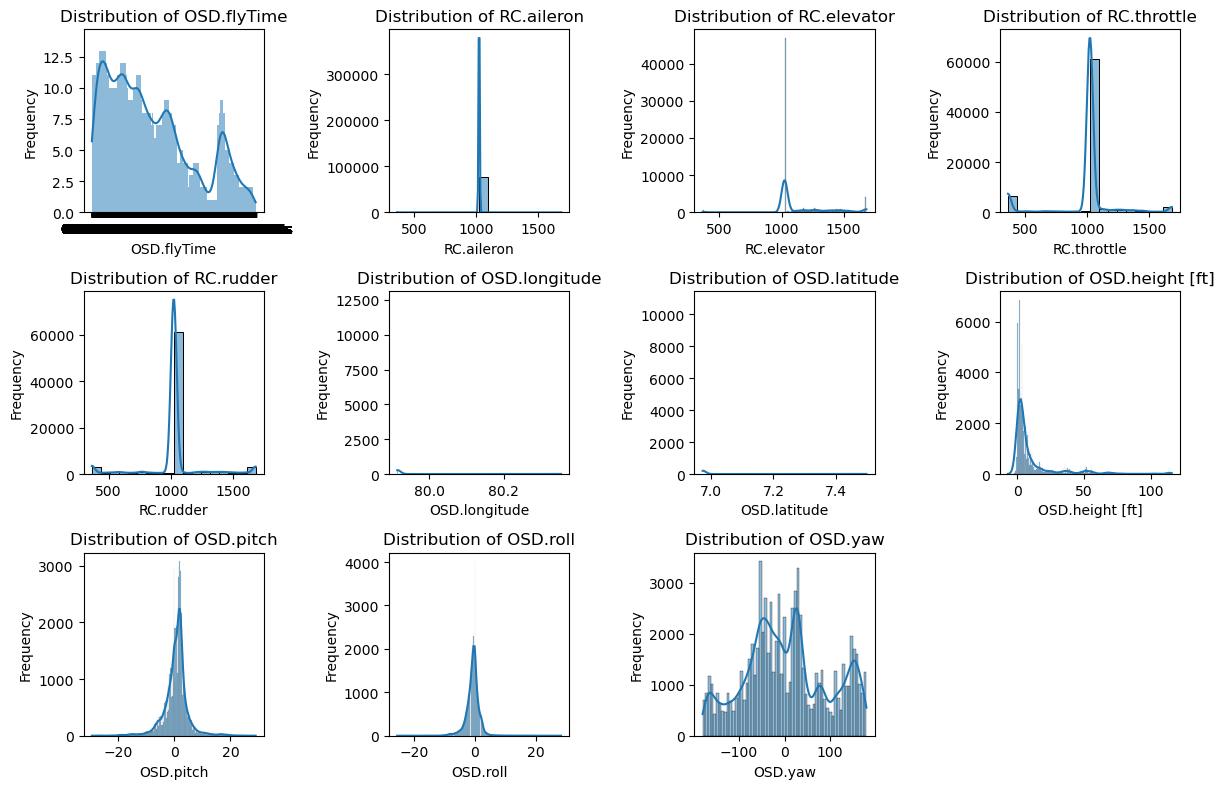

In [93]:
# Plot histograms for each feature
plt.figure(figsize=(12, 8))
for i, feature in enumerate(df.columns):
    plt.subplot(3, 4, i+1)
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Convert latitude and longitude into Cartesian coordinates

In [46]:
import pandas as pd
import math

# Define a function to convert latitude and longitude to local Cartesian coordinates
def convert_to_cartesian(row, origin_lat, origin_lon):
    # Calculate the differences between the current point and the origin
    delta_lat = row['OSD.latitude'] - origin_lat
    delta_lon = row['OSD.longitude'] - origin_lon
    
    # Convert the differences to meters using an appropriate conversion factor
    # For simplicity, assuming 1 degree of latitude = 111.32 km and 1 degree of longitude = 111.32 km * cos(latitude)
    lat_to_m = 111320.0  # meters per degree of latitude at the equator
    lon_to_m = 111320.0 * abs(math.cos(math.radians(origin_lat)))  # meters per degree of longitude
    
    # Calculate the x and y coordinates in meters
    x = delta_lon * lon_to_m
    y = delta_lat * lat_to_m
    
    return pd.Series([x, y])  # Return a Series with two values

# Assume 'df' is your DataFrame with columns 'OSD.latitude' and 'OSD.longitude'
# Define your local projection origin point
origin_lat = df['OSD.latitude'].iloc[0]  # Latitude of the first point in the DataFrame
origin_lon = df['OSD.longitude'].iloc[0]  # Longitude of the first point in the DataFrame

# Apply the conversion function to each row and create new columns for local Cartesian coordinates
df[['local_x', 'local_y']] = df.apply(convert_to_cartesian, args=(origin_lat, origin_lon), axis=1)

# Scale the Cartesian coordinates between -1 and 1 using Min-Max scaling
df['OSD.latitude'] = 2 * (df['local_x'] - df['local_x'].min()) / (df['local_x'].max() - df['local_x'].min()) - 1
df['OSD.longitude'] = 2 * (df['local_y'] - df['local_y'].min()) / (df['local_y'].max() - df['local_y'].min()) - 1

# Drop the 'local_x' and 'local_y' columns
df.drop(columns=['local_x', 'local_y'], inplace=True)

# Print the DataFrame
df.head()


,OSD.flyTime,RC.aileron,RC.elevator,RC.throttle,RC.rudder,OSD.longitude,OSD.latitude,OSD.height [ft],OSD.pitch,OSD.roll,OSD.yaw
0,0.0,1024,1024,1024,1024,0.999882,0.999001,0.0,5.7,2.5,113.9
1,0.1,1024,1024,1024,1024,0.999882,0.999002,0.0,5.7,2.5,114.0
2,0.2,1024,1024,1024,1024,0.999882,0.999002,0.0,5.7,2.5,114.0
3,0.3,1024,1024,1024,1024,0.999881,0.999002,0.0,5.7,2.5,114.0
4,0.4,1024,1024,1024,1024,0.999881,0.999002,0.0,5.7,2.5,114.1


# Data Cleaning

### Remove Null values

In [47]:
null_counts = df.isnull().sum(axis=0)
print(null_counts)

OSD.flyTime        0
RC.aileron         0
RC.elevator        0
RC.throttle        0
RC.rudder          0
OSD.longitude      0
OSD.latitude       0
OSD.height [ft]    0
OSD.pitch          0
OSD.roll           0
OSD.yaw            0
dtype: int64


## Identify Outliers

<Figure size 1500x1000 with 0 Axes>

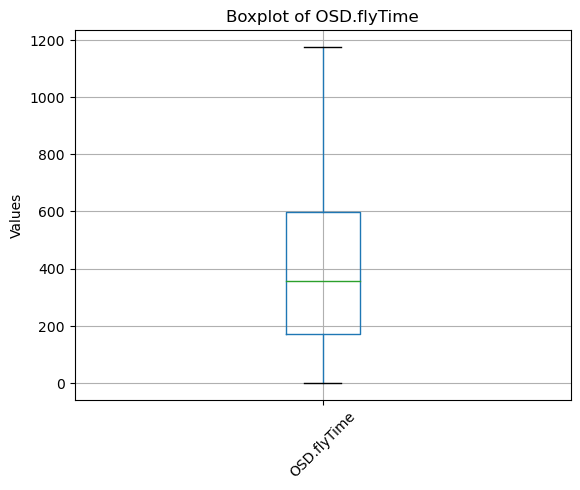

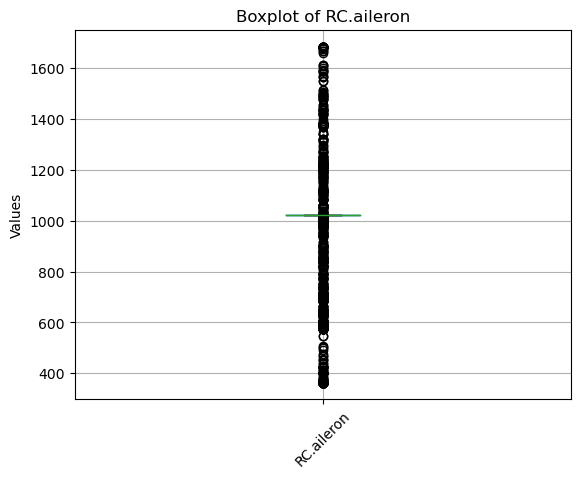

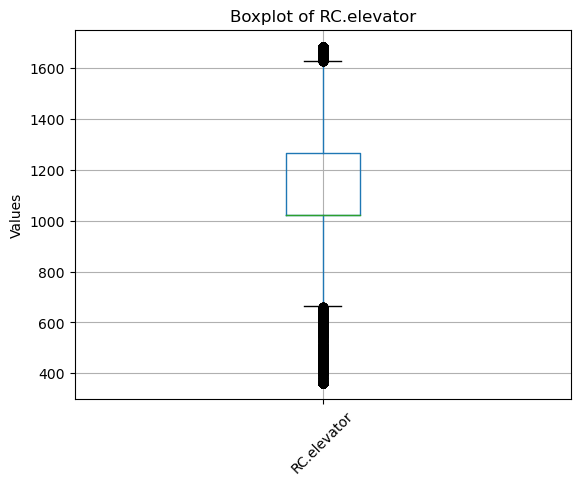

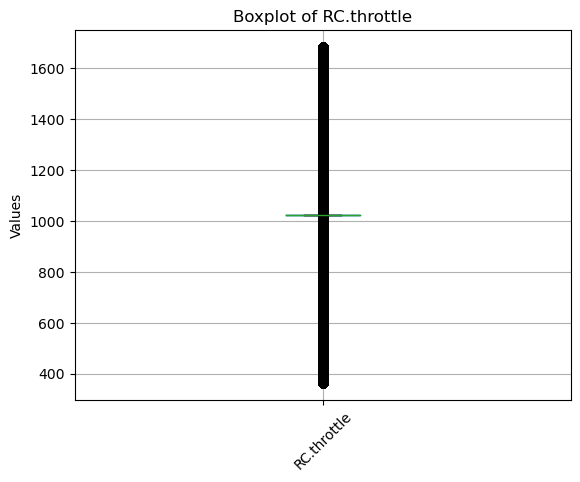

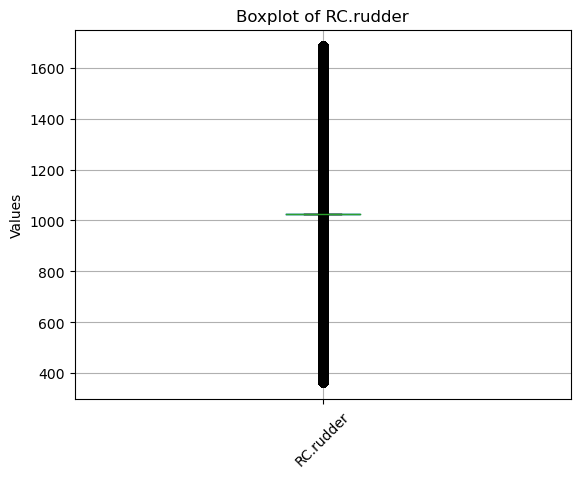

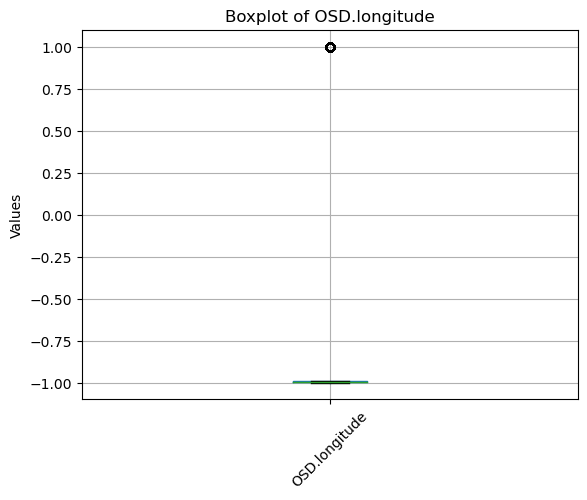

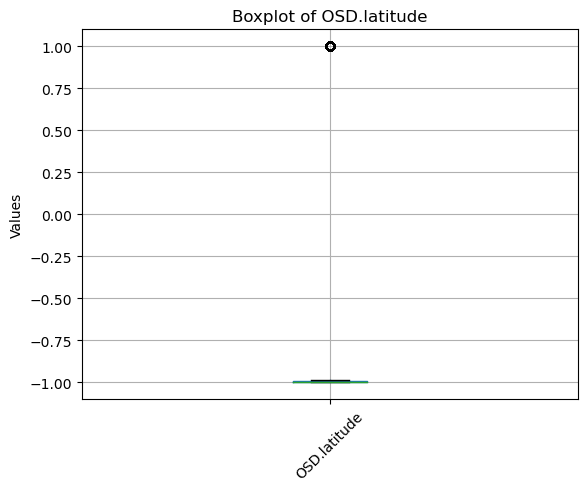

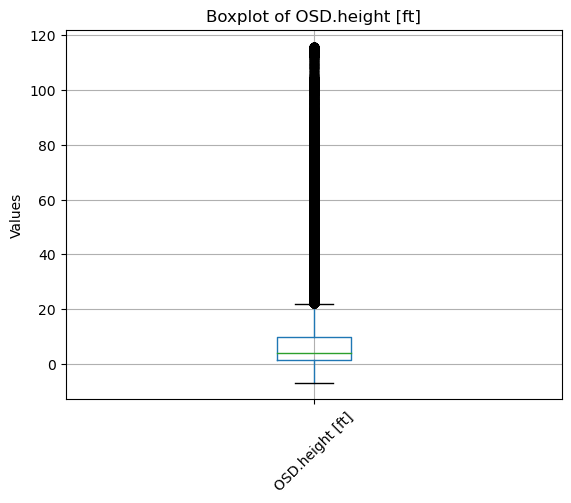

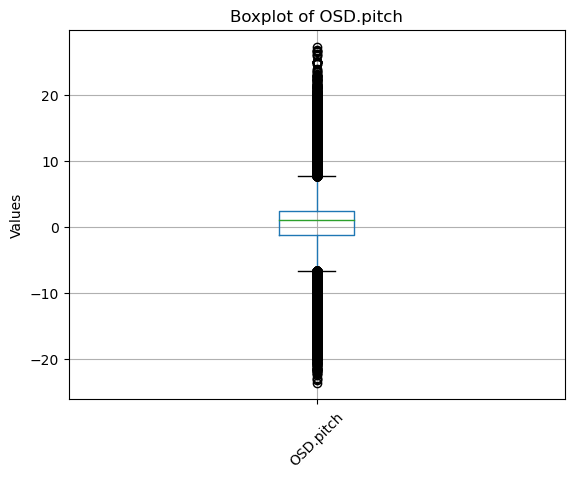

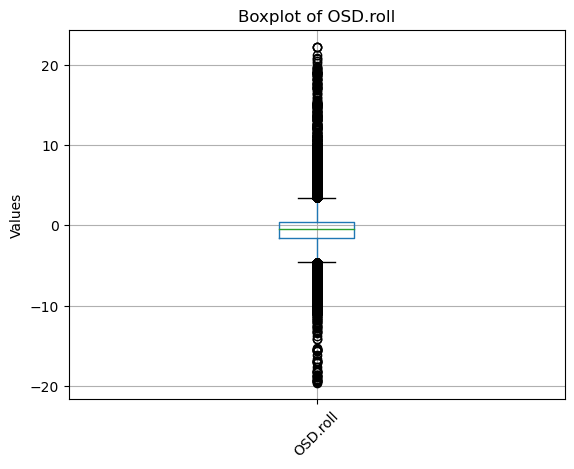

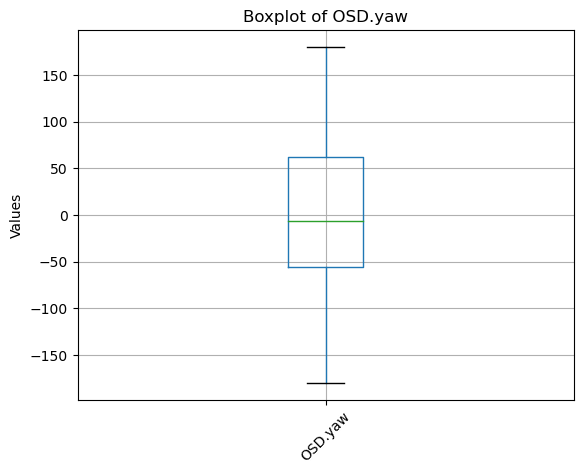

In [48]:
plt.figure(figsize=(15, 10))
for column in df.columns:
    plt.figure()
    df.boxplot(column=[column])
    plt.title(f'Boxplot of {column}')
    plt.ylabel('Values')
    plt.xticks(rotation=45)
    plt.show()

#  calculate outliers before apply  two_sided_median_filter

### Number of outliers for each feature

Number of outliers for each feature:
OSD.flyTime: 0
RC.aileron: 855
RC.elevator: 5709
RC.throttle: 16468
RC.rudder: 15864
OSD.longitude: 2577
OSD.latitude: 2577
OSD.height [ft]: 9306
OSD.pitch: 5789
OSD.roll: 4538
OSD.yaw: 0
Total number of outliers: 63683


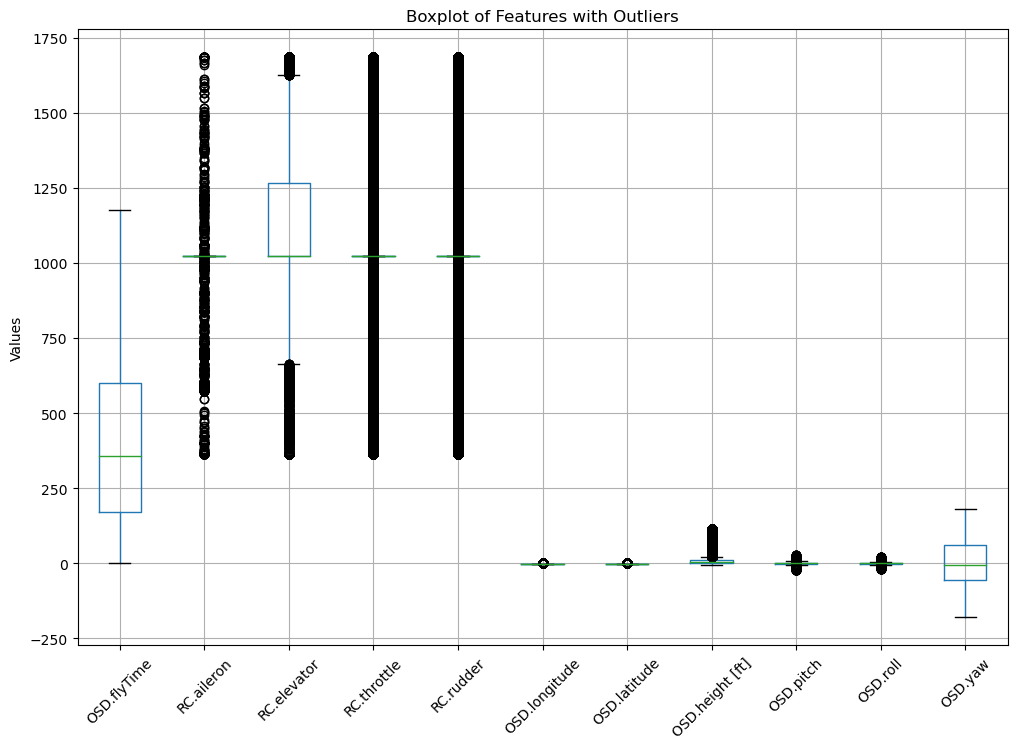

In [49]:
import matplotlib.pyplot as plt

# Initialize an empty dictionary to store the number of outliers for each feature
outliers_count = {}

# Initialize total outliers count
total_outliers_count = 0

# Calculate the first quartile (Q1) and third quartile (Q3) for each feature
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

# Calculate the interquartile range (IQR) for each feature
IQR = Q3 - Q1

# Define the lower and upper bounds for each feature
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Loop through each feature and count the number of outliers
for feature in df.columns:
    outliers_count[feature] = ((df[feature] < lower_bound[feature]) | (df[feature] > upper_bound[feature])).sum()
    total_outliers_count += ((df[feature] < lower_bound[feature]) | (df[feature] > upper_bound[feature])).sum()

# Display the number of outliers for each feature
print("Number of outliers for each feature:")
for feature, count in outliers_count.items():
    print(f"{feature}: {count}")

# Display the total number of outliers
print("Total number of outliers:", total_outliers_count)

# Plot boxplots for each feature
plt.figure(figsize=(12, 8))
df.boxplot()
plt.title("Boxplot of Features with Outliers")
plt.xticks(rotation=45)
plt.ylabel("Values")
plt.show()


### Total outliers by rowise

#### In the first code snippet, outliers are counted for each feature individually, and then the total number of outliers is obtained by summing up these counts. This approach counts the outliers separately for each feature, resulting in a higher total count because it's possible for a data point to be an outlier in multiple features.In the second code snippet, outliers are detected based on whether any feature in a row exceeds the lower or upper bounds. This approach counts the total number of rows with at least one outlier, which may result in a lower total count because each row is counted only once, regardless of how many features in that row contain outliers.

In [50]:
# Calculate the first quartile (Q1) and third quartile (Q3)
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

# Calculate the interquartile range (IQR)
IQR = Q3 - Q1

# Define the lower and upper bounds for outliers detection
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detect outliers
outliers = ((df < lower_bound) | (df > upper_bound)).any(axis=1)

# Print number of outliers
print("Number of outliers:", outliers.sum())


Number of outliers: 42805


# Handle the Outliers

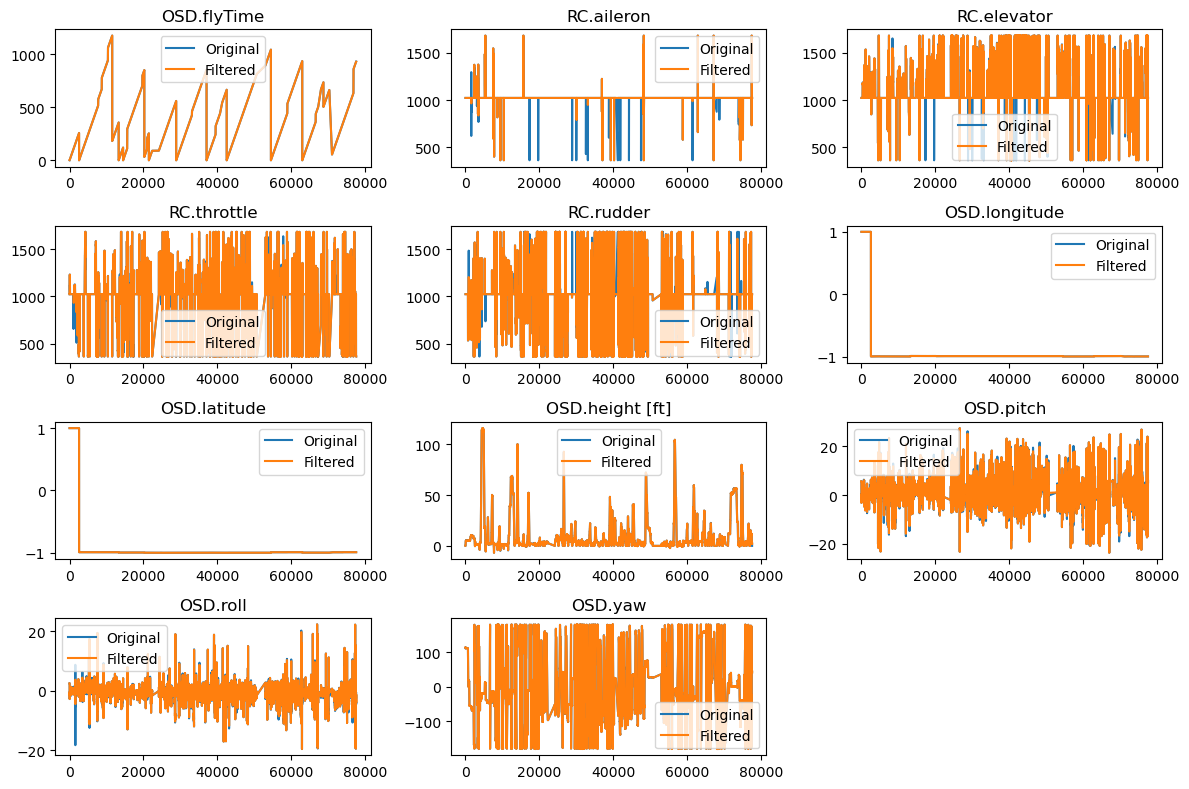

In [51]:
def two_sided_median_filter(data, window_size):
    """
    Perform two-sided median filtering for outlier detection.

    Parameters:
    - data: 1D numpy array containing the flight data
    - window_size: Size of the window for median filtering

    Returns:
    - filtered_data: Numpy array with outliers replaced by the median value of neighboring elements
    """
    filtered_data = np.zeros_like(data)
    half_window = window_size // 2

    for i in range(len(data)):
        lower_bound = max(0, i - half_window)
        upper_bound = min(len(data), i + half_window + 1)

        window = data[lower_bound:upper_bound]
        if len(window) > 0:  # Check if window is not empty
            median = np.median(window)

            if data[i] < median - 1.5 * np.median(np.abs(window - median)):
                filtered_data[i] = median
            elif data[i] > median + 1.5 * np.median(np.abs(window - median)):
                filtered_data[i] = median
            else:
                filtered_data[i] = data[i]
        else:
            # If window is empty, set the filtered value to the original value
            filtered_data[i] = data[i]

    return filtered_data


# Apply two-sided median filtering to each feature
window_size = 7  # You can adjust the window size as needed
for feature in features:
    df[feature + '_filtered'] = two_sided_median_filter(df[feature].values, window_size)

# Plot original and filtered dataa for each feature
plt.figure(figsize=(12, 8))
for i, feature in enumerate(features):
    plt.subplot(4, 3, i+1)
    plt.plot(df[feature], label='Original')
    plt.plot(df[feature + '_filtered'], label='Filtered')
    plt.title(feature)
    plt.legend()
plt.tight_layout()
plt.show()

# calculate outliers after apply two_sided_median_filter

In [52]:
# Calculate residuals
residuals = np.abs(df[feature] - df[feature + '_filtered'])

# Define threshold (e.g., based on median absolute deviation)
median_absolute_deviation = np.median(residuals)
threshold = 3 * median_absolute_deviation  # Adjust multiplier as needed

# Count outliers
outliers_count = np.sum(residuals > threshold)

print("Number of outliers detected:", outliers_count)


Number of outliers detected: 7166


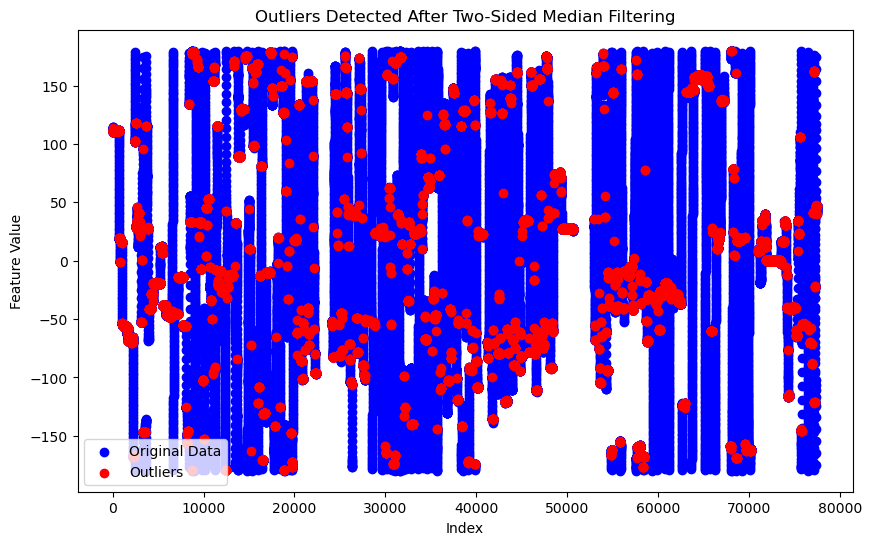

In [53]:
# Calculate residuals
residuals = np.abs(df[feature] - df[feature + '_filtered'])

# Define threshold (e.g., based on median absolute deviation)
median_absolute_deviation = np.median(residuals)
threshold = 3 * median_absolute_deviation  # Adjust multiplier as needed

# Identify outliers
outliers = df[residuals > threshold]

# Visualize outliers
plt.figure(figsize=(10, 6))
plt.scatter(df.index, df[feature], c='blue', label='Original Data')
plt.scatter(outliers.index, outliers[feature], c='red', label='Outliers')
plt.title('Outliers Detected After Two-Sided Median Filtering')
plt.xlabel('Index')
plt.ylabel('Feature Value')
plt.legend()
plt.show()


In [54]:
# Filter outliers
filtered_df = df[residuals <= threshold]

# Display the shape of the filtered DataFrame before and after removing outliers
print("Shape of original DataFrame:", df.shape)
print("Shape of filtered DataFrame (after removing outliers):", filtered_df.shape)


Shape of original DataFrame: (71522, 22)
Shape of filtered DataFrame (after removing outliers): (64356, 22)


In [55]:
df=filtered_df
df=df[features]
df

,OSD.flyTime,RC.aileron,RC.elevator,RC.throttle,RC.rudder,OSD.longitude,OSD.latitude,OSD.height [ft],OSD.pitch,OSD.roll,OSD.yaw
1,0.1,1024,1024,1024,1024,0.999882,0.999002,0.0,5.7,2.5,114.0
2,0.2,1024,1024,1024,1024,0.999882,0.999002,0.0,5.7,2.5,114.0
3,0.3,1024,1024,1024,1024,0.999881,0.999002,0.0,5.7,2.5,114.0
4,0.4,1024,1024,1024,1024,0.999881,0.999002,0.0,5.7,2.5,114.1
5,0.5,1024,1024,1024,1024,0.999881,0.999002,0.0,5.7,2.5,114.1
...,...,...,...,...,...,...,...,...,...,...,...
77530,931.0,1024,1024,364,1024,-0.998428,-0.990589,1.9,6.2,-3.7,42.7
77531,931.1,1024,1024,364,1024,-0.998428,-0.990589,1.9,6.0,-3.7,42.4
77532,931.2,1024,1024,364,1024,-0.998427,-0.990588,1.9,5.3,-3.6,42.0
77533,931.3,1024,1024,364,1024,-0.998427,-0.990588,1.9,4.8,-1.5,41.5


In [56]:
# Define a function to calculate outliers based on a criterion
def calculate_outliers(data, criterion):
    """
    Calculate outliers based on a criterion.

    Parameters:
    - data: 1D numpy array containing the feature data
    - criterion: Criterion for defining outliers (e.g., threshold value)

    Returns:
    - num_outliers: Number of outliers in the feature data
    """
    # Calculate median or mean of the data
    data_median = np.median(data)
    # Identify outliers based on the criterion
    outliers = data[data > criterion * data_median]
    # Count the number of outliers
    num_outliers = len(outliers)
    return num_outliers

# Define a threshold for identifying outliers (e.g., 1.5 times the median)
threshold = 1.5

# Calculate the number of outliers for each feature
num_outliers_per_feature = {}
for feature in features:
    num_outliers_per_feature[feature] = calculate_outliers(df[feature].values, threshold)

# Print the number of outliers for each feature
for feature, num_outliers in num_outliers_per_feature.items():
    print(f"Number of outliers in {feature}: {num_outliers}")


Number of outliers in OSD.flyTime: 20498
Number of outliers in RC.aileron: 56
Number of outliers in RC.elevator: 5578
Number of outliers in RC.throttle: 1583
Number of outliers in RC.rudder: 3409
Number of outliers in OSD.longitude: 64356
Number of outliers in OSD.latitude: 64356
Number of outliers in OSD.height [ft]: 23468
Number of outliers in OSD.pitch: 26284
Number of outliers in OSD.roll: 36658
Number of outliers in OSD.yaw: 32633


# Normalize other features

In [57]:
# Instantiate the StandardScaler
scaler = StandardScaler()

# Define the columns to normalize
columns_to_normalize = ['OSD.flyTime','RC.aileron','RC.elevator','RC.throttle','RC.rudder','OSD.longitude','OSD.latitude','OSD.height [ft]','OSD.pitch','OSD.roll','OSD.yaw']

# Apply StandardScaler to the specified columns
df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])
df.head()

,OSD.flyTime,RC.aileron,RC.elevator,RC.throttle,RC.rudder,OSD.longitude,OSD.latitude,OSD.height [ft],OSD.pitch,OSD.roll,OSD.yaw
1,-1.459063,0.035987,-0.524142,0.128677,-0.018592,5.436911,5.434930,-0.573543,1.215106,1.40385,1.195496
2,-1.458700,0.035987,-0.524142,0.128677,-0.018592,5.436910,5.434931,-0.573543,1.215106,1.40385,1.195496
3,-1.458337,0.035987,-0.524142,0.128677,-0.018592,5.436910,5.434931,-0.573543,1.215106,1.40385,1.195496
4,-1.457975,0.035987,-0.524142,0.128677,-0.018592,5.436909,5.434930,-0.573543,1.215106,1.40385,1.196584
5,-1.457612,0.035987,-0.524142,0.128677,-0.018592,5.436909,5.434931,-0.573543,1.215106,1.40385,1.196584


Range of values for each feature:
                       min        max
OSD.flyTime      -1.459425   2.805511
RC.aileron      -15.477998  15.549973
RC.elevator      -3.369749   2.321465
RC.throttle      -2.733116   2.990470
RC.rudder        -2.830512   2.793327
OSD.longitude    -0.198525   5.437244
OSD.latitude     -0.196858   5.437742
OSD.height [ft]  -0.941015   5.684283
OSD.pitch        -5.702859   6.338651
OSD.roll         -8.237189  10.036963
OSD.yaw          -2.003597   1.912815


<Figure size 1200x600 with 0 Axes>

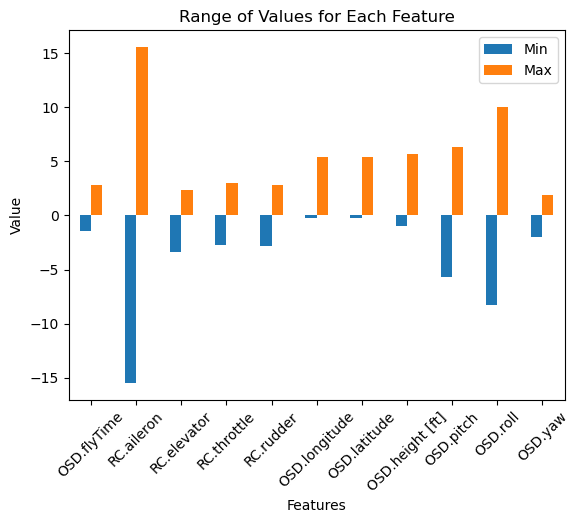

In [58]:
feature_ranges = df.describe().loc[['min', 'max']]

# Transpose the DataFrame for easier plotting
feature_ranges = feature_ranges.transpose()

print("Range of values for each feature:")
print(feature_ranges)
# Plot the range of values for each feature
plt.figure(figsize=(12, 6))
feature_ranges.plot(kind='bar', rot=45)
plt.title('Range of Values for Each Feature')
plt.xlabel('Features')
plt.ylabel('Value')
plt.legend(['Min', 'Max'])
plt.show()

Number of outliers for each feature:
OSD.flyTime: 0
RC.aileron: 746
RC.elevator: 4982
RC.throttle: 14567
RC.rudder: 15578
OSD.longitude: 2106
OSD.latitude: 2106
OSD.height [ft]: 7922
OSD.pitch: 5415
OSD.roll: 4758
OSD.yaw: 0
Total number of outliers: 58180


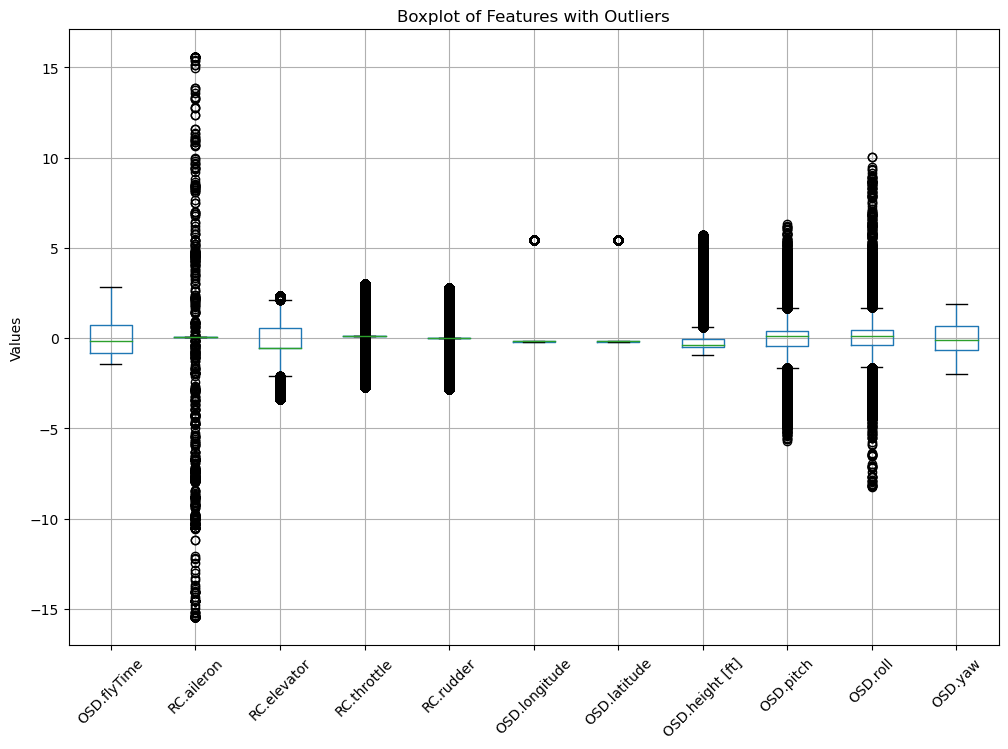

In [59]:
# Initialize an empty dictionary to store the number of outliers for each feature
outliers_count = {}

# Initialize total outliers count
total_outliers_count = 0

# Calculate the first quartile (Q1) and third quartile (Q3) for each feature
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

# Calculate the interquartile range (IQR) for each feature
IQR = Q3 - Q1

# Define the lower and upper bounds for each feature
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Loop through each feature and count the number of outliers
for feature in df.columns:
    outliers_count[feature] = ((df[feature] < lower_bound[feature]) | (df[feature] > upper_bound[feature])).sum()
    total_outliers_count += ((df[feature] < lower_bound[feature]) | (df[feature] > upper_bound[feature])).sum()

# Display the number of outliers for each feature
print("Number of outliers for each feature:")
for feature, count in outliers_count.items():
    print(f"{feature}: {count}")

# Display the total number of outliers
print("Total number of outliers:", total_outliers_count)

# Plot boxplots for each feature
plt.figure(figsize=(12, 8))
df.boxplot()
plt.title("Boxplot of Features with Outliers")
plt.xticks(rotation=45)
plt.ylabel("Values")
plt.show()


# Distribution of each features

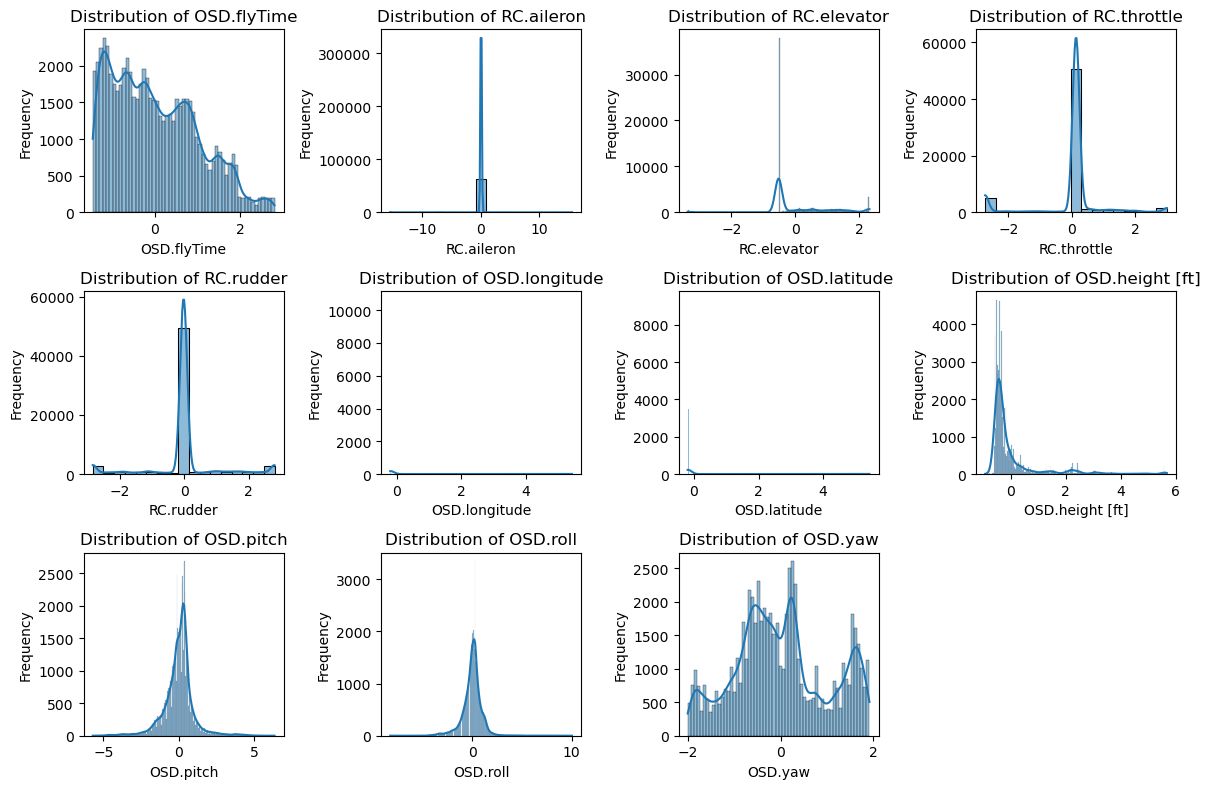

In [61]:
# Plot histograms for each feature
plt.figure(figsize=(12, 8))
for i, feature in enumerate(df.columns):
    plt.subplot(3, 4, i+1)
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

Correlation Matrix:


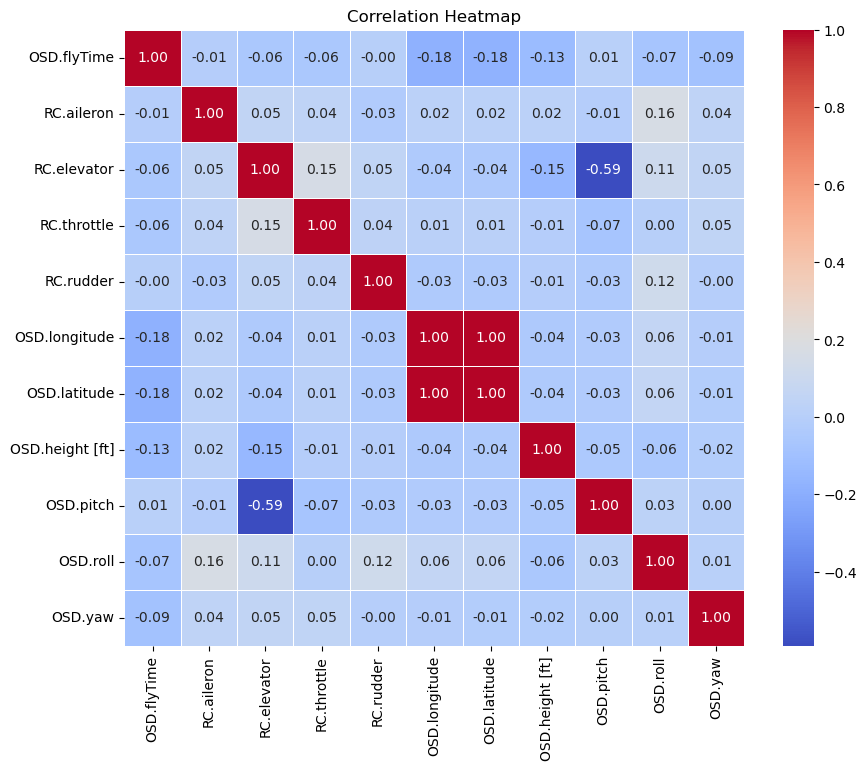

In [28]:
# Calculate correlation matrix
correlation_matrix = df.corr()

# Print correlation matrix
print("Correlation Matrix:")
correlation_matrix

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [29]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split

input_features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder']
output_targets = ['OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

# Splitting the dataset into features and target variables
X = df[input_features]
y = df[output_targets]

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Reshape input data for LSTM
X_train_lstm = X_train.values.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = X_test.values.reshape((X_test.shape[0], 1, X_test.shape[1]))

# Define the LSTM model
model_lstm = Sequential()
model_lstm.add(LSTM(units=128, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), dropout=0.3, recurrent_dropout=0.3, return_sequences=True))
model_lstm.add(LSTM(units=128, dropout=0.3, recurrent_dropout=0.3))
model_lstm.add(Dense(units=len(output_targets)))  # Output layer

# Compile the model
model_lstm.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mean_squared_error')

# Train the model
model_lstm.fit(X_train_lstm, y_train, epochs=50, batch_size=32, verbose=1)

# Evaluate the model
mse_lstm = model_lstm.evaluate(X_test_lstm, y_test)

# Make predictions
y_pred_lstm = model_lstm.predict(X_test_lstm)



Epoch 1/50

1609/1609 [==============================] - 22s 8ms/step - loss: 0.9179
Epoch 2/50
1609/1609 [==============================] - 12s 7ms/step - loss: 0.9013
Epoch 3/50
1609/1609 [==============================] - 12s 8ms/step - loss: 0.8868
Epoch 4/50
1609/1609 [==============================] - 11s 7ms/step - loss: 0.8745
Epoch 5/50
1609/1609 [==============================] - 11s 7ms/step - loss: 0.8636
Epoch 6/50
1609/1609 [==============================] - 12s 7ms/step - loss: 0.8562
Epoch 7/50
1609/1609 [==============================] - 12s 8ms/step - loss: 0.8493
Epoch 8/50
1609/1609 [==============================] - 14s 9ms/step - loss: 0.8421
Epoch 9/50
1609/1609 [==============================] - 14s 9ms/step - loss: 0.8405
Epoch 10/50
1609/1609 [==============================] - 14s 8ms/step - loss: 0.8339
Epoch 11/50
1609/1609 [==============================] - 13s 8ms/step - loss: 0.8275
Epoch 12/50
1609/1609 [==============================] - 11s 7ms/step - 

31/31 [==============================] - 0s 3ms/step
OSD.longitude - Mean Squared Error: 8.71, R-squared: -12.20%, Mean Absolute Error: 2.16, Variance Explained: -12.20%
OSD.latitude - Mean Squared Error: 8.67, R-squared: -203.24%, Mean Absolute Error: 2.51, Variance Explained: -203.24%
OSD.height [ft] - Mean Squared Error: 2.57, R-squared: -344.68%, Mean Absolute Error: 1.49, Variance Explained: -344.68%
OSD.pitch - Mean Squared Error: 5.65, R-squared: -11.68%, Mean Absolute Error: 1.62, Variance Explained: -11.68%
OSD.roll - Mean Squared Error: 0.93, R-squared: -7.62%, Mean Absolute Error: 0.80, Variance Explained: -7.62%
OSD.yaw - Mean Squared Error: 9219.11, R-squared: -18.28%, Mean Absolute Error: 82.62, Variance Explained: -18.28%


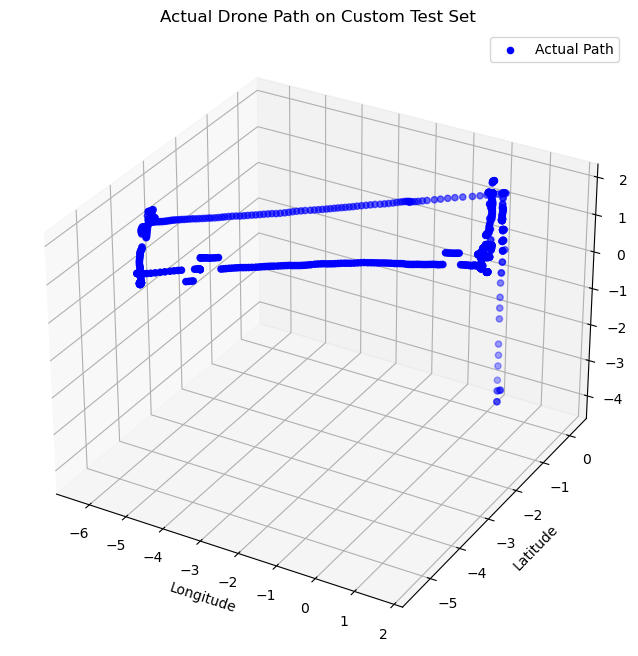

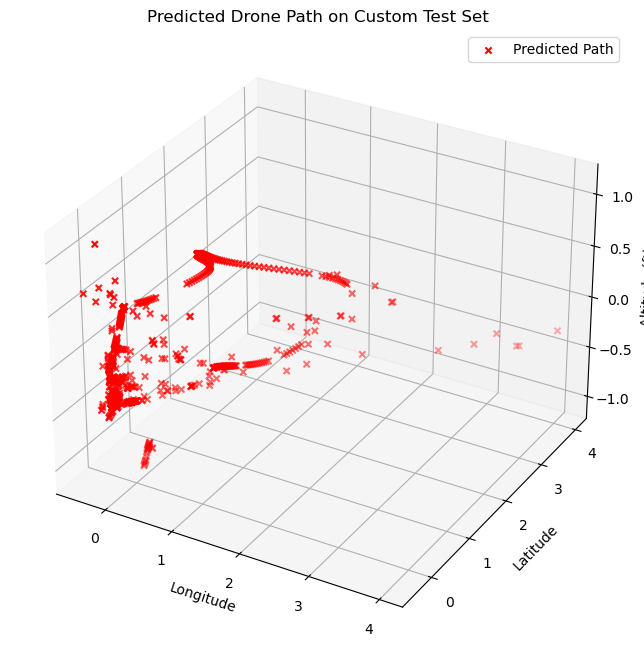

In [35]:
import os
import math
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.model_selection import train_test_split

input_features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder']
output_targets = ['OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

# Define a function to convert latitude and longitude to local Cartesian coordinates
def convert_to_cartesian(row, origin_lat, origin_lon):
    # Calculate the differences between the current point and the origin
    delta_lat = row['OSD.latitude'] - origin_lat
    delta_lon = row['OSD.longitude'] - origin_lon

    lat_to_m = 111320.0  # meters per degree of latitude at the equator
    lon_to_m = 111320.0 * abs(math.cos(math.radians(origin_lat)))  # meters per degree of longitude
    
    # Calculate the x and y coordinates in meters
    x = delta_lon * lon_to_m
    y = delta_lat * lat_to_m
    
    return pd.Series([x, y])  # Return a Series with two values

# Read the custom test dataset
test_folder = 'testing'
test_files = [os.path.join(test_folder, file) for file in os.listdir(test_folder) if file.endswith('.csv')]
df_test_custom = pd.concat([pd.read_csv(file) for file in test_files], ignore_index=True)

# Preprocess 'OSD.flyTime' column in the test dataset
df_test_custom['OSD.flyTime'] = df_test_custom['OSD.flyTime'].apply(time_to_seconds)

# Define your local projection origin point
origin_lat = df_test_custom['OSD.latitude'].iloc[0]  # Latitude of the first point in the DataFrame
origin_lon = df_test_custom['OSD.longitude'].iloc[0]  # Longitude of the first point in the DataFrame

# Apply the conversion function to each row and create new columns for local Cartesian coordinates
df_test_custom[['local_x', 'local_y']] = df_test_custom.apply(convert_to_cartesian, args=(origin_lat, origin_lon), axis=1)

# Keep the latitude and longitude columns and replace their values with 'local_x' and 'local_y' respectively
df_test_custom['OSD.latitude'] = df_test_custom['local_x']
df_test_custom['OSD.longitude'] = df_test_custom['local_y']

# Drop the 'local_x' and 'local_y' columns if needed
df_test_custom.drop(columns=['local_x', 'local_y'], inplace=True)

df1=df_test_custom
# Define a threshold for distance below which data points are considered duplicates (e.g., 0.0001 degrees)
threshold_distance = 0.000001
# Calculate distances between consecutive data points
distances = ((df1['OSD.latitude'].diff() ** 2) + (df1['OSD.longitude'].diff() ** 2)) ** 0.5
# Mark consecutive duplicate rows with True, excluding the first occurrence
duplicates = distances < threshold_distance
# Include the first occurrence
duplicates.iloc[0] = False
# Remove duplicate rows from the DataFrame
df_cleaned = df1[~duplicates]
# Reset the index if needed
df_cleaned.reset_index(drop=True, inplace=True)

df_test_custom=df_cleaned

features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder','OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']
df_test_custom=df_test_custom[features]

# Normalization using StandardScaler
scaler = StandardScaler()
df_test_custom_scaled = scaler.fit_transform(df_test_custom[['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder','OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']])

X_test_custom_scaled = df_test_custom_scaled[:, :5]  # Select the first 5 columns after scaling
X_test_custom_lstm = X_test_custom_scaled.reshape((X_test_custom_scaled.shape[0], 1, X_test_custom_scaled.shape[1]))

# Make predictions on the custom test set
y_pred_custom = model_lstm.predict(X_test_custom_lstm)

# Calculate and display accuracy metrics for each target variable on the custom test set
for i, target_variable in enumerate(output_targets):
    mse_custom = mean_squared_error(df_test_custom[target_variable], y_pred_custom[:, i])
    r2_custom = r2_score(df_test_custom[target_variable], y_pred_custom[:, i])
    mae_custom = mean_absolute_error(df_test_custom[target_variable], y_pred_custom[:, i])
    variance_explained_custom = 100 * (1 - mse_custom / np.var(df_test_custom[target_variable]))
    
    print(f'{target_variable} - Mean Squared Error: {mse_custom:.2f}, R-squared: {r2_custom:.2%}, Mean Absolute Error: {mae_custom:.2f}, Variance Explained: {variance_explained_custom:.2f}%')


# Create a 3D plot for the actual drone path on custom test set
fig_actual_custom = plt.figure(figsize=(12, 8))
ax_actual_custom = fig_actual_custom.add_subplot(111, projection='3d')
ax_actual_custom.scatter(df_test_custom['OSD.longitude'], df_test_custom['OSD.latitude'], df_test_custom['OSD.height [ft]'], c='blue', marker='o', label='Actual Path')
ax_actual_custom.set_xlabel('Longitude')
ax_actual_custom.set_ylabel('Latitude')
ax_actual_custom.set_zlabel('Altitude (ft)')
ax_actual_custom.set_title('Actual Drone Path on Custom Test Set')
ax_actual_custom.legend()

# Create a 3D plot for the predicted drone path on custom test set
fig_predicted_custom = plt.figure(figsize=(12, 8))
ax_predicted_custom = fig_predicted_custom.add_subplot(111, projection='3d')
ax_predicted_custom.scatter(y_pred_custom[:, 0], y_pred_custom[:, 1], y_pred_custom[:, 2], c='red', marker='x', label='Predicted Path')
ax_predicted_custom.set_xlabel('Longitude')
ax_predicted_custom.set_ylabel('Latitude')
ax_predicted_custom.set_zlabel('Altitude (ft)')
ax_predicted_custom.set_title('Predicted Drone Path on Custom Test Set')
ax_predicted_custom.legend()

# Show the actual and predicted path plots on the custom test set
plt.show()
